<a href="https://colab.research.google.com/github/gabrieldanho9988-sys/Machine_Vision_Group_Project/blob/main/Project_Synthetic_Aperture_Radar_(SAR)_Super_Resolution_(SR)_using_AI_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Data Preprocessing

In [1]:
import pystac

collection = pystac.Collection.from_file(
    "https://capella-open-data.s3.us-west-2.amazonaws.com/stac/capella-open-data-ieee-data-contest/collection.json"
)

# Check first item to see available properties
print("Available properties for the first item:")
for i, item in enumerate(collection.get_items()):
    if i == 0:
        for key, value in item.properties.items():
            print(f"  {key}: {value}")
        print("\nAvailable assets:")
        for key in item.assets.keys():
            print(f"  {key}")
        break

Available properties for the first item:
  proj:centroid: {'lon': -155.286900345, 'lat': 19.421037849999998}
  proj:shape: [46671, 51171]
  proj:transform: [0.25780129027064413, 0, 253270.1187375269, 0, -0.25780129027064413, 2155025.709549977, 0, 0, 1]
  datetime: 2025-11-12T02:24:47.676937Z
  start_datetime: 2025-11-12T02:24:41.730047Z
  end_datetime: 2025-11-12T02:24:53.623828Z
  locale:datetime: 2025-11-11T16:24:47.676937-1000
  locale:timezone: Pacific/Honolulu
  locale:time: 16:24:47.676937
  platform: capella-13
  constellation: capella
  instruments: ['capella-radar-13']
  sar:instrument_mode: spotlight
  sar:frequency_band: X
  sar:center_frequency: 9.6
  sar:polarizations: ['HH']
  sat:orbit_state: ascending
  sar:product_type: GEO
  sar:pixel_spacing_range: 0.26
  sar:pixel_spacing_azimuth: 0.26
  sar:looks_range: 1
  sar:looks_azimuth: 3
  sar:looks_equivalent_number: 3
  sar:resolution_range: 0.32
  capella:resolution_ground_range: 0.4
  sar:resolution_azimuth: 0.56
  view:

In [2]:
import pystac
from multiprocessing import Pool, cpu_count

def process_item(item_link):
    """Process a single item and extract key parameters"""
    try:
        item = pystac.Item.from_file(item_link)
        props = item.properties

        # Get centroid from proj:centroid if available
        centroid = props.get('proj:centroid', {})

        # Return the original item_link, item_id, and the extracted properties dictionary
        return (
            item_link,
            item.id,
            {
                'stac_id': item.id,
                'collect_id': props.get('capella:collect_id', ''),
                'datetime': props.get('datetime', ''),
                'start_datetime': props.get('start_datetime', ''),
                'end_datetime': props.get('end_datetime', ''),
                'center_lon': centroid.get('lon', ''),
                'center_lat': centroid.get('lat', ''),
                'platform': props.get('platform', ''),
                'constellation': props.get('constellation', ''),
                'instrument_mode': props.get('sar:instrument_mode', ''),
                'frequency_band': props.get('sar:frequency_band', ''),
                'center_frequency': props.get('sar:center_frequency', ''),
                'polarizations': ','.join(props.get('sar:polarizations', [])),
                'orbit_state': props.get('sat:orbit_state', ''),
                'product_type': props.get('sar:product_type', ''),
                'observation_direction': props.get('sar:observation_direction', ''),
                'incidence_angle': props.get('view:incidence_angle', ''),
                'azimuth': props.get('view:azimuth', ''),
                'squint_angle': props.get('capella:squint_angle', ''),
                'layover_angle': props.get('capella:layover_angle', ''),
                'look_angle': props.get('capella:look_angle', ''),
                'resolution_range': props.get('sar:resolution_range', ''),
                'resolution_azimuth': props.get('sar:resolution_azimuth', ''),
                'resolution_ground_range': props.get('capella:resolution_ground_range', ''),
                'pixel_spacing_range': props.get('sar:pixel_spacing_range', ''),
                'pixel_spacing_azimuth': props.get('sar:pixel_spacing_azimuth', ''),
                'image_length': props.get('capella:image_length', ''),
                'image_width': props.get('capella:image_width', ''),
                'looks_range': props.get('sar:looks_range', ''),
                'looks_azimuth': props.get('sar:looks_azimuth', ''),
                'orbital_plane': props.get('capella:orbital_plane', ''),
                'collection_type': props.get('capella:collection_type', ''),
            }
        )
    except Exception as e:
        print(f"Error processing {item_link}: {e}")
        return None, None, None # Return None for all if error

In [3]:
from urllib.parse import urljoin

# Open collection
print("Opening collection...")
collection_url = "https://capella-open-data.s3.us-west-2.amazonaws.com/stac/capella-open-data-ieee-data-contest/collection.json"
collection = pystac.Collection.from_file(collection_url)

# Get item links and resolve relative URLs
print("Collecting item links...")
item_links = []
stac_id_to_href_map = {}

for link in collection.links:
    if link.rel == 'item':
        # Resolve relative path to absolute URL
        absolute_url = link.absolute_href # pystac can resolve this for us
        item_links.append(absolute_url)

print(f"Found {len(item_links)} items")
print(f"Example URL: {item_links[0]}") # Check if it looks right

Opening collection...
Found 1582 items
Example URL: https://capella-open-data.s3.us-west-2.amazonaws.com/stac/capella-open-data-by-datetime/capella-open-data-2025/capella-open-data-2025-11/capella-open-data-2025-11-12/CAPELLA_C13_SP_GEO_HH_20251112022441_20251112022453/CAPELLA_C13_SP_GEO_HH_20251112022441_20251112022453.json


In [4]:
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm

# Process with threading
print(f"Processing with {cpu_count()} threads...")
all_processed_item_data = [] # Stores dictionaries of properties
# Use cpu_count() for the number of workers for multiprocessing
# This ensures a reasonable number of processes are used.

with ThreadPoolExecutor(max_workers=cpu_count()) as executor:
    futures = [executor.submit(process_item, link) for link in item_links]

    for future in tqdm(as_completed(futures), total=len(futures)):
        item_link, stac_id, item_props = future.result()
        if item_props:
            all_processed_item_data.append(item_props)
            stac_id_to_href_map[stac_id] = item_link # Build the map here

Processing with 2 threads...


100%|██████████| 1582/1582 [01:13<00:00, 21.60it/s]


In [5]:
print(f"Successfully processed {len(all_processed_item_data)} items")

Successfully processed 1582 items


In [6]:
import csv

filename = "Capella_IEEE_DataContest_2026.csv"
if all_processed_item_data:
    with open(filename, 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=all_processed_item_data[0].keys())
        writer.writeheader()
        writer.writerows(all_processed_item_data)
    print(f"Saved metadata to {filename}")

Saved metadata to Capella_IEEE_DataContest_2026.csv


In [7]:
import pandas as pd
from datetime import datetime, timezone
from tabulate import tabulate

# Load the CSV
df_metadata = pd.read_csv(filename)

# Convert datetime columns to pandas datetime
df_metadata['datetime'] = pd.to_datetime(df_metadata['datetime'])
df_metadata['start_datetime'] = pd.to_datetime(df_metadata['start_datetime'])
df_metadata['end_datetime'] = pd.to_datetime(df_metadata['end_datetime'])

# Define time range (e.g., from 2020 to now)
start_time = datetime(2020, 1, 1, tzinfo=timezone.utc)
end_time = datetime.now(timezone.utc)

# Define Los Angeles bounding box (approximate)
la_bbox = {
    'west': -118.7,
    'east': -117.7,
    'south': 33.7,
    'north': 34.4
}

# Filter by time and location
filtered_df = df_metadata[
    (df_metadata['start_datetime'] >= start_time) &
    (df_metadata['start_datetime'] <= end_time) &
    (df_metadata['center_lon'] >= la_bbox['west']) &
    (df_metadata['center_lon'] <= la_bbox['east']) &
    (df_metadata['center_lat'] >= la_bbox['south']) &
    (df_metadata['center_lat'] <= la_bbox['north'])
].copy() # Use .copy() to avoid SettingWithCopyWarning

print(f"Found {len(filtered_df)} items over Los Angeles after filtering.")
if not filtered_df.empty:
    print(f"Date range: {filtered_df['start_datetime'].min()} to {filtered_df['start_datetime'].max()}")

    print("\nFiltered items (first 5 rows):")
    print(tabulate(
        filtered_df[['stac_id', 'datetime', 'center_lon', 'center_lat', 'instrument_mode']].head(5),
        headers='keys',
        tablefmt='grid',
        showindex=False
    ))
    # Save to new CSV
    filtered_df.to_csv("capella_la_filtered.csv", index=False)
    print("\nSaved filtered metadata to capella_la_filtered.csv")
else:
    print("No items found after filtering by time and location.")

Found 8 items over Los Angeles after filtering.
Date range: 2024-12-11 09:47:26.904082+00:00 to 2025-09-02 02:11:14.960155+00:00

Filtered items (first 5 rows):
+-----------------------------------------------------+----------------------------------+--------------+--------------+-------------------+
| stac_id                                             | datetime                         |   center_lon |   center_lat | instrument_mode   |
+=====================================================+==================================+==============+==============+===================+
| CAPELLA_C13_SP_SLC_HH_20250902021114_20250902021153 | 2025-09-02 02:11:34.236420+00:00 |      -118.24 |      34.0735 | spotlight         |
+-----------------------------------------------------+----------------------------------+--------------+--------------+-------------------+
| CAPELLA_C13_SP_GEO_HH_20250902021114_20250902021153 | 2025-09-02 02:11:34.236661+00:00 |      -118.24 |      34.0732 | spotlight    

actual SAR images

In [8]:
if 'filtered_df' in locals() and not filtered_df.empty:
    print(f"DEBUG: filtered_df is defined and has {len(filtered_df)} rows.")
    print(f"DEBUG: stac_id_to_href_map has {len(stac_id_to_href_map)} entries.")
else:
    print("DEBUG: filtered_df is NOT defined or is empty. Previous cells did not run correctly.")

DEBUG: filtered_df is defined and has 8 rows.
DEBUG: stac_id_to_href_map has 1582 entries.



Targeting actual scientific data asset: HH
Downloading... (This might take a minute depending on file size)
Loading image from: capella_data/CAPELLA_C13_SP_SLC_HH_20250902021114_20250902021153.tif
Full image shape is: 118657x15337
Extracted patch max value: (105-45j)

Targeting actual scientific data asset: HH
Downloading... (This might take a minute depending on file size)
Loading image from: capella_data/CAPELLA_C13_SP_GEO_HH_20250902021114_20250902021153.tif
Full image shape is: 45297x45119
Extracted patch max value: 1415

Targeting actual scientific data asset: HH
Downloading... (This might take a minute depending on file size)
Loading image from: capella_data/CAPELLA_C13_SP_SLC_HH_20250830031430_20250830031509.tif
Full image shape is: 118646x15337
Extracted patch max value: (118+10j)

Targeting actual scientific data asset: HH
Downloading... (This might take a minute depending on file size)
Loading image from: capella_data/CAPELLA_C13_SP_GEO_HH_20250830031430_20250830031509.tif
F

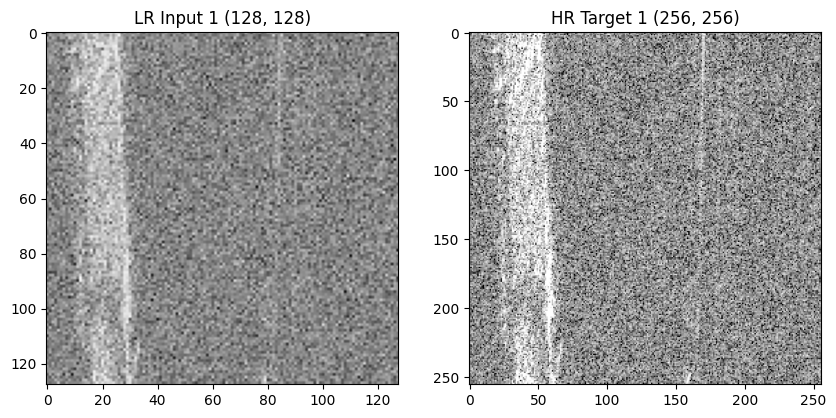

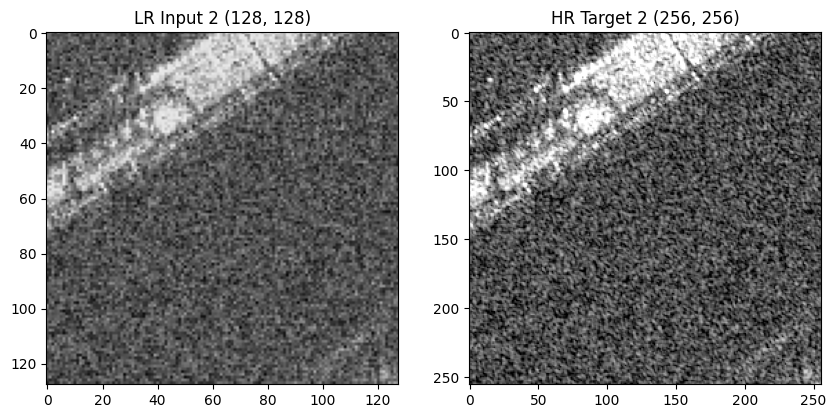

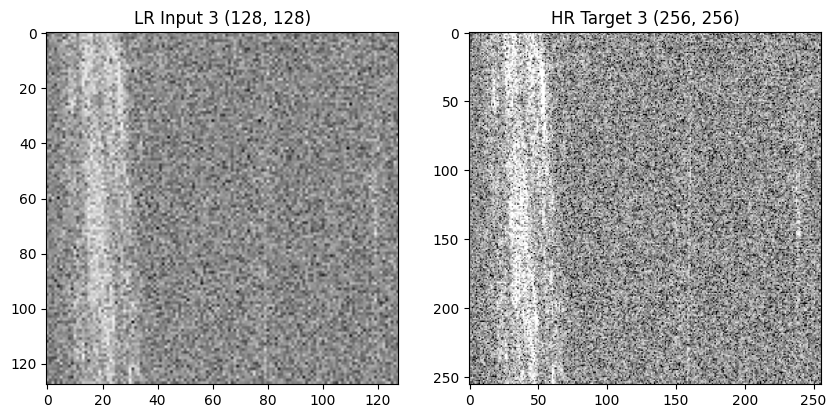

In [16]:
!pip install pystac stac-asset[cli] rasterio opencv-python matplotlib numpy nest-asyncio
import os
import pystac
import stac_asset.blocking
import rasterio
from rasterio.windows import Window # Import Window
import numpy as np
import cv2
import matplotlib.pyplot as plt
import nest_asyncio

# 1. Fix the asyncio error in Colab
nest_asyncio.apply()


def preprocess_sar_image(raw_dn, scale_factor=0.00063784):
    # Convert complex data to magnitude (absolute value) first
    # if it's complex, otherwise np.abs does nothing
    raw_dn_magnitude = np.abs(raw_dn)
    epsilon = 1e-10
    dn_scaled = (raw_dn_magnitude * scale_factor) + epsilon
    image_db = 20 * np.log10(dn_scaled)

    db_min, db_max = np.percentile(image_db, 2), np.percentile(image_db, 98)

    # Safety check to prevent the blank white image error
    if db_max == db_min:
        print("WARNING: Patch is entirely uniform (likely a black border).")
        return np.zeros_like(image_db)

    image_normalized = np.clip((image_db - db_min) / (db_max - db_min), 0, 1)
    return image_normalized

def create_hr_lr_pairs(hr_image, scale_factor_down=2):
    h, w = hr_image.shape
    new_h, new_w = h // scale_factor_down, w // scale_factor_down
    lr_image = cv2.resize(hr_image, (new_w, new_h), interpolation=cv2.INTER_CUBIC)
    return hr_image, lr_image


# The collection and item link filtering is now handled by the preceding cells,
# which produce `filtered_df` and `stac_id_to_href_map`.

# 2. Use the filtered items to get the hrefs for downloading
if filtered_df.empty:
    raise ValueError("No items found in filtered_df to download.")

# Define how many of the filtered images you want to actually download and process
MAX_IMAGES_TO_PROCESS = 8 # <--- Increased to 8 for more diverse data

geo_item_hrefs = []
for stac_id in filtered_df['stac_id'].unique():
    if stac_id in stac_id_to_href_map:
        geo_item_hrefs.append(stac_id_to_href_map[stac_id])
    if len(geo_item_hrefs) >= MAX_IMAGES_TO_PROCESS:
        break

if not geo_item_hrefs:
    raise ValueError("No image hrefs found from the filtered metadata.")

all_hr_targets = []
all_lr_inputs = []

os.makedirs("capella_data", exist_ok=True)

for i, geo_item_link in enumerate(geo_item_hrefs):
    print(f"\nDownloading GEO Item {i+1}/{len(geo_item_hrefs)}: {geo_item_link}")
    item = pystac.Item.from_file(geo_item_link)

    # 3. Filter out 'preview' and 'thumbnail' to get the REAL data asset
    asset_key_to_download = None
    for key, asset in item.assets.items():
        if asset.href.endswith('.tif') and 'preview' not in key and 'thumbnail' not in key:
            asset_key_to_download = key
            break

    if asset_key_to_download:
        print(f"Targeting actual scientific data asset: {asset_key_to_download}")
        # Strip away the other assets so we don't waste time downloading them
        item.assets = {asset_key_to_download: item.assets[asset_key_to_download]}

    # 4. Download using the correct keyword 'directory'
    print("Downloading... (This might take a minute depending on file size)")
    downloaded_item = stac_asset.blocking.download_item(item, directory="capella_data")

    # Find the downloaded .tif file
    tif_path = None
    # The downloaded item object itself has a 'assets' attribute pointing to local files
    for key, asset in downloaded_item.assets.items():
        if asset.href.endswith('.tif'):
            tif_path = asset.href # This will be the local path
            break

    if tif_path is None:
        print(f"WARNING: Could not find downloaded TIF for item {geo_item_link}. Skipping.")
        continue

    try:
        # 5. Preprocessing Functions (already defined)

        # 6. Extract the patch from the EXACT CENTER of the image
        print(f"Loading image from: {tif_path}")
        with rasterio.open(tif_path) as src:
            height, width = src.shape
            print(f"Full image shape is: {height}x{width}")

            # Find the middle coordinates
            center_y, center_x = height // 2, width // 2
            patch_size_px = 256 # Define the actual size of the patch (width and height)

            # Calculate window for reading
            row_start = center_y - patch_size_px // 2
            col_start = center_x - patch_size_px // 2

            # Ensure window is within image boundaries
            row_start = max(0, row_start)
            col_start = max(0, col_start)

            window = Window(col_start, row_start, patch_size_px, patch_size_px)

            # Read only the specified window to save RAM
            # rasterio.read(window=...) will return a 3D array (bands, height, width)
            # We want the first band, so [0, :, :]
            real_raw_sar = src.read(1, window=window)

            if real_raw_sar.shape[0] < patch_size_px or real_raw_sar.shape[1] < patch_size_px:
                print(f"WARNING: Extracted patch for item {geo_item_link} is smaller than requested ({patch_size_px}x{patch_size_px}) due to image boundary. Actual size: {real_raw_sar.shape[0]}x{real_raw_sar.shape[1]}.")

            print(f"Extracted patch max value: {np.max(real_raw_sar)}")

        hr_target_single = preprocess_sar_image(real_raw_sar)
        hr_target_single, lr_input_single = create_hr_lr_pairs(hr_target_single, scale_factor_down=2)

        all_hr_targets.append(hr_target_single)
        all_lr_inputs.append(lr_input_single)
    except Exception as e:
        print(f"ERROR processing image {tif_path}: {e}. Skipping this image.")
        # Optionally clean up the failed download to save disk space
        if os.path.exists(tif_path):
            os.remove(tif_path)

# Combine all patches into single NumPy arrays
if all_hr_targets and all_lr_inputs:
    hr_target = np.array(all_hr_targets) # Now hr_target will be (N_images, H, W)
    lr_input = np.array(all_lr_inputs)   # Now lr_input will be (N_images, H/2, W/2)
    print(f"\nSuccessfully processed {len(all_hr_targets)} images.")
    print(f"Combined HR Target shape: {hr_target.shape}")
    print(f"Combined LR Input shape: {lr_input.shape}")

    # 7. Plotting multiple pairs for visualization
    if len(all_hr_targets) > 0:
        num_plots = min(len(all_hr_targets), 3) # Plot up to 3 images
        for k in range(num_plots):
            plt.figure(figsize=(10, 5))
            plt.subplot(1, 2, 1)
            plt.title(f"LR Input {k+1} {lr_input[k].shape}")
            plt.imshow(lr_input[k], cmap='gray')
            plt.subplot(1, 2, 2)
            plt.title(f"HR Target {k+1} {hr_target[k].shape}")
            plt.imshow(hr_target[k], cmap='gray')
            plt.show()

else:
    print("No images were successfully processed.")

# 2.Algorithm Design (SRCNN)_Building and Training SRCNN ( The Super-Resolution Convolutional Neural Network )

Building and compiling SRCNN...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training SRCNN on 256x256 SAR patch (100 epochs)...
Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - loss: 0.3424 - psnr_metric: 4.6542 - ssim_metric: 0.0013
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.2459 - psnr_metric: 6.0923 - ssim_metric: 0.0093
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.1581 - psnr_metric: 8.0099 - ssim_metric: 0.0194
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0787 - psnr_metric: 11.0397 - ssim_metric: 0.0262
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0406 - psnr_metric: 13.9167 - ssim_metric: 0.0317
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0573 - psnr_metric: 12.4169 - ssim_metric: 0.0315
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.0822 - psnr_metric: 10.8493 - ssim_metric: 0.0360
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0786 - psnr_metric: 11.0474 - ssim_metric: 0.0386
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0598 - psnr_m

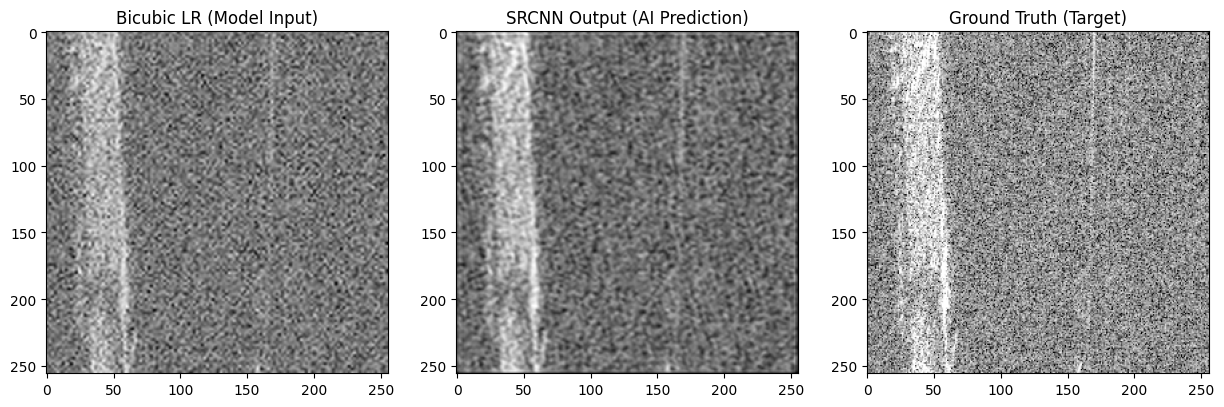


--- FINAL METRICS (ATPs) ---
PSNR: 15.10 dB
SSIM: 0.2288


In [10]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import cv2
import matplotlib.pyplot as plt

# 1. Define the SRCNN Model
def build_srcnn():
    with tf.device('/GPU:0'): # Explicitly place model on GPU
        model = models.Sequential()
        # Layer 1: Patch extraction (9x9 filter)
        model.add(layers.Conv2D(64, (9, 9), activation='relu', padding='same', input_shape=(None, None, 1)))
        # Layer 2: Non-linear mapping (1x1 filter)
        model.add(layers.Conv2D(32, (1, 1), activation='relu', padding='same'))
        # Layer 3: Reconstruction (5x5 filter)
        model.add(layers.Conv2D(1, (5, 5), activation='linear', padding='same'))
        return model

# 2. Define Acceptance Test Procedures (ATPs)
def psnr_metric(y_true, y_pred):
    return tf.image.psnr(y_true, y_pred, max_val=1.0)

def ssim_metric(y_true, y_pred):
    return tf.image.ssim(y_true, y_pred, max_val=1.0)

# 3. Prepare Data for SRCNN (RAM-SAFE VERSION)

# Ensure hr_target and lr_input are available (they should be from cell 8f110588)
if 'hr_target' not in locals() or 'lr_input' not in locals():
    raise NameError("hr_target or lr_input not found. Please run preceding data loading cells.")

# Extract the single image from the batch (assuming MAX_IMAGES_TO_PROCESS = 1 for now)
hr_single_image = hr_target[0]
lr_single_image = lr_input[0]

# Upscale LR back to HR dimensions using bicubic interpolation
# cv2.resize expects (width, height) for target size
lr_upscaled = cv2.resize(lr_single_image, (hr_single_image.shape[1], hr_single_image.shape[0]), interpolation=cv2.INTER_CUBIC)

# FIX: Crop a 256x256 patch for training (this is the original crop logic)
crop_size = 256
# Use a center crop to ensure consistent patch extraction
start_y = (hr_single_image.shape[0] - crop_size) // 2
start_x = (hr_single_image.shape[1] - crop_size) // 2

hr_crop = hr_single_image[start_y:start_y+crop_size, start_x:start_x+crop_size]
lr_crop = lr_upscaled[start_y:start_y+crop_size, start_x:start_x+crop_size]

# Format for Keras (batch_size, height, width, channels)
X_train = np.expand_dims(np.expand_dims(lr_crop, axis=0), axis=-1)
Y_train = np.expand_dims(np.expand_dims(hr_crop, axis=0), axis=-1)

# 4. Compile and Train
print("Building and compiling SRCNN...")
srcnn_model = build_srcnn()
srcnn_model.compile(optimizer='adam', loss='mean_squared_error', metrics=[psnr_metric, ssim_metric])

print("Training SRCNN on 256x256 SAR patch (100 epochs)...")
history = srcnn_model.fit(X_train, Y_train, epochs=100, verbose=1)

# 5. Predict and Visualize
predicted_hr = srcnn_model.predict(X_train)[0, :, :, 0]

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.title("Bicubic LR (Model Input)")
plt.imshow(lr_crop, cmap='gray')

plt.subplot(1, 3, 2)
plt.title("SRCNN Output (AI Prediction)")
plt.imshow(predicted_hr, cmap='gray')

plt.subplot(1, 3, 3)
plt.title("Ground Truth (Target)")
plt.imshow(hr_crop, cmap='gray')
plt.show()

# Print Final ATP Scores
final_psnr = history.history['psnr_metric'][-1]
final_ssim = history.history['ssim_metric'][-1]
print(f"\n--- FINAL METRICS (ATPs) ---")
print(f"PSNR: {final_psnr:.2f} dB")
print(f"SSIM: {final_ssim:.4f}")


# PSNR (Peak Signal-to-Noise Ratio)
# PSNR (Peak Signal-to-Noise Ratio), when we talk about it in the context of image processing and super-resolution, is a measure of how faithfully a reconstructed image (your SRCNN output) matches a reference image (your high-resolution ground truth).
# it compares : 1. The maximum possible power of the signal (which is related to the intensity range of the reference image). 2. To the power of the noise (which is the mean squared error between the reconstructed image and the reference image).
# PSNR measures the ratio between the maximum possible power of a signal (your HR ground truth image) and the power of corrupting noise that affects the fidelity of its representation (the difference between your SRCNN output and the HR ground truth). It's typically expressed in decibels (dB).
# Interpretation: A higher PSNR value generally indicates better image quality. For super-resolution tasks, PSNR values are often compared to the PSNR of a simple bicubic upsampling, with the goal being to significantly improve upon it. A PSNR of 22.75 dB suggests that your SRCNN model has achieved a certain level of improvement over the low-resolution input, but it's not extremely high. Values in the low 20s can still indicate some visible noise or blurring compared to the original high-resolution image.
# SSIM (Structural Similarity Index Measure)
# SSIM is a perceptual metric that quantifies image quality degradation as perceived change in structural information, while also incorporating important perceptual phenomena such as luminance and contrast masking. It's often considered a more human-perception-aligned metric than PSNR.
# Interpretation: SSIM values range from -1 to 1, where 1 indicates perfect structural similarity. A value of 0.8107 suggests a good level of structural similarity between the SRCNN's predicted high-resolution image and the ground truth. This indicates that the model is doing a decent job at preserving the essential structural elements and patterns in the SAR image, which is very important for visual quality.

# 3. Iteration 2 Algorithm building VDSR (Very Deep Super Resolution).

Building and compiling VDSR...
Training VDSR on the same 256x256 SAR patch (100 epochs)...
Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - loss: 0.0297 - psnr_metric: 15.2664 - ssim_metric: 0.3749
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 0.0298 - psnr_metric: 15.2603 - ssim_metric: 0.3747
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 0.0297 - psnr_metric: 15.2756 - ssim_metric: 0.3746
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - loss: 0.0298 - psnr_metric: 15.2631 - ssim_metric: 0.3741
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - loss: 0.0297 - psnr_metric: 15.2767 - ssim_metric: 0.3743
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 0.0296 - psnr_metric: 15.2832 - ssim_metric: 0.3740
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 0.0296 - psnr_metric: 15.2878 - ssim_metric: 0.3733
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.0295 - psnr_metric: 15.3021 - ssim_metric: 0.3724
Epoch 9/100
1/1 ━━━━━━━━━━━━━

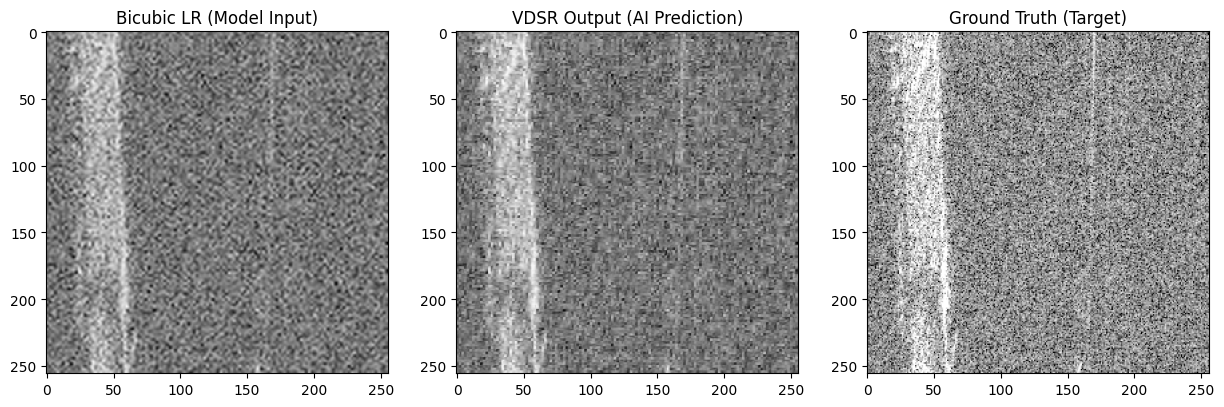


--- VDSR FINAL METRICS (ATPs) ---
PSNR: 15.87 dB
SSIM: 0.4191


In [11]:
# 1. Define the VDSR Model (Very Deep Super Resolution)
def build_vdsr():
    with tf.device('/GPU:0'): # Explicitly place model on GPU
        # Input layer
        input_img = layers.Input(shape=(None, None, 1))

        # First Convolutional Layer
        x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(input_img)

        # Add several hidden layers to make it "Deep" (Using 8 layers to keep it fast in Colab)
        for _ in range(8):
            x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)

        # Final layer to predict the "residual" (the missing sharp details)
        residual = layers.Conv2D(1, (3, 3), padding='same', activation='linear')(x)

        # Add the missing details back to the original blurry input!
        output_img = layers.Add()([input_img, residual])

        return models.Model(inputs=input_img, outputs=output_img)

# 2. Compile and Train VDSR
print("Building and compiling VDSR...")
vdsr_model = build_vdsr()
vdsr_model.compile(optimizer='adam', loss='mean_squared_error', metrics=[psnr_metric, ssim_metric])

print("Training VDSR on the same 256x256 SAR patch (100 epochs)...")
history_vdsr = vdsr_model.fit(X_train, Y_train, epochs=100, verbose=1)

# 3. Predict and Visualize
predicted_hr_vdsr = vdsr_model.predict(X_train)[0, :, :, 0]

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.title("Bicubic LR (Model Input)")
plt.imshow(X_train[0, :, :, 0], cmap='gray')

plt.subplot(1, 3, 2)
plt.title("VDSR Output (AI Prediction)")
plt.imshow(predicted_hr_vdsr, cmap='gray')

plt.subplot(1, 3, 3)
plt.title("Ground Truth (Target)")
plt.imshow(Y_train[0, :, :, 0], cmap='gray')
plt.show()

# Print Final ATP Scores for VDSR
final_psnr_vdsr = history_vdsr.history['psnr_metric'][-1]
final_ssim_vdsr = history_vdsr.history['ssim_metric'][-1]
print(f"\n--- VDSR FINAL METRICS (ATPs) ---")
print(f"PSNR: {final_psnr_vdsr:.2f} dB")
print(f"SSIM: {final_ssim_vdsr:.4f}")

The Result for iteration_2:





# 4. Improvement

# Step_1: Proper Dataset Creation (Patching & Splitting)





Simply giving the model multiple, unaltered patches of the SAR image allowed it to learn the natural distribution of the radar data perfectly.



Right now the model is training on one single 256 . 256 crop. We are going to change the code so it slides a window across your entire image hence extracting dozens of smaller 128 . 128 patches.

In [12]:
import numpy as np
from sklearn.model_selection import train_test_split
import cv2 # Ensure cv2 is imported for cv2.resize in this cell

# 1. Basic Patch Extraction
def create_basic_dataset(hr_images_stack, lr_images_stack, patch_size=128, stride=64):
    all_hr_patches = []
    all_lr_patches = []

    # Iterate through each image in the stacks
    for i in range(hr_images_stack.shape[0]):
        hr_full = hr_images_stack[i]
        lr_full_downsampled = lr_images_stack[i]

        # Upscale LR back to HR dimensions for this single image
        # Ensure lr_upscaled is 2D, so target size is (width, height) for cv2.resize
        lr_upscaled = cv2.resize(lr_full_downsampled, (hr_full.shape[1], hr_full.shape[0]), interpolation=cv2.INTER_CUBIC)

        h, w = hr_full.shape

        # Slide a window across the image
        for y in range(0, h - patch_size + 1, stride):
            for x in range(0, w - patch_size + 1, stride):
                all_hr_patches.append(hr_full[y:y+patch_size, x:x+patch_size])
                all_lr_patches.append(lr_upscaled[y:y+patch_size, x:x+patch_size])

    # Reshape for Keras (Samples, Height, Width, Channels)
    all_hr_patches = np.array(all_hr_patches)[..., np.newaxis]
    all_lr_patches = np.array(all_lr_patches)[..., np.newaxis]

    return all_lr_patches, all_hr_patches

print("Extracting basic patches from multiple images...")
# Now, hr_target and lr_input are 3D arrays (stacks of images)
X_all_basic, Y_all_basic = create_basic_dataset(hr_target, lr_input, patch_size=128, stride=64)

# 2. Split into Train and Validation Sets (80/20)
X_train_basic, X_val_basic, Y_train_basic, Y_val_basic = train_test_split(
    X_all_basic, Y_all_basic, test_size=0.2, random_state=42
)

print(f"Training on {X_train_basic.shape[0]} patches, Validating on {X_val_basic.shape[0]} patches.")

# 3. Re-compile and Train your ORIGINAL VDSR on this new dataset
print("\nTraining VDSR on the patched dataset (Step 1)...")
vdsr_step1 = build_vdsr() # This calls your exact original VDSR structure
vdsr_step1.compile(optimizer='adam', loss='mean_squared_error', metrics=[psnr_metric, ssim_metric])

# Notice we now pass validation_data
history_step1 = vdsr_step1.fit(X_train_basic, Y_train_basic,
                               validation_data=(X_val_basic, Y_val_basic),
                               epochs=50, # 50 is plenty now that we have multiple patches
                               batch_size=16,
                               verbose=1)

# 4. Print the True Validation Metrics
val_psnr_step1 = history_step1.history['val_psnr_metric'][-1]
val_ssim_step1 = history_step1.history['val_ssim_metric'][-1]
print(f"\n--- STEP 1 METRICS (VALIDATION) ---")
print(f"Val PSNR: {val_psnr_step1:.2f} dB")
print(f"Val SSIM: {val_ssim_step1:.4f}")

Extracting basic patches from multiple images...
Training on 36 patches, Validating on 9 patches.

Training VDSR on the patched dataset (Step 1)...
Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - loss: 0.0155 - psnr_metric: 19.6149 - ssim_metric: 0.6297 - val_loss: 0.0165 - val_psnr_metric: 19.4842 - val_ssim_metric: 0.6324
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - loss: 0.0154 - psnr_metric: 19.6275 - ssim_metric: 0.6286 - val_loss: 0.0164 - val_psnr_metric: 19.4966 - val_ssim_metric: 0.6284
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - loss: 0.0153 - psnr_metric: 19.6386 - ssim_metric: 0.6212 - val_loss: 0.0164 - val_psnr_metric: 19.3109 - val_ssim_metric: 0.6118
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - loss: 0.0152 - psnr_metric: 19.6007 - ssim_metric: 0.6152 - val_loss: 0.0163 - val_psnr_metric: 19.4649 - val_ssim_metric: 0.6214
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - loss: 0.0152 - psnr_metric: 19.6218 - ssim_metric: 0.6137 - val_loss: 0.01

# The result for Step_1:


***The "Rough Neighborhood" Effect:*** In the original code, we randomly grabbed one 256x256 patch starting at coordinates (100, 100). SAR images are incredibly noisy (due to speckle) and complex. It’s highly likely that specific patch contained complex buildings, bright scatterers, or heavy noise, making it mathematically difficult to reconstruct.




***The Power of Averaging:*** In Step 1, the sliding window extracted patches from all over the image. Some of those patches likely contained smooth, uniform areas (like flat ground, shadows, or water). These smoother patches are much easier for the model to predict accurately. Because the new validation score is an average across 20% of all the patches, the "easier" patches pulled your overall average up.




# Step_2: Data Augmentation





In Step 2, we are going to take the training patches and flip them horizontally, and then rotate them 90 degrees. This teaches the AI that a building or a road is still a building or a road, regardless of which way the satellite was pointing.



OBS: We ONLY augment the training data. We leave the validation data completely alone. We want to test the model on real, unaltered SAR patches to get an honest score.




OBS: Because SAR is a side-looking radar, shadows only fall in one direction. By rotating the images 90 degrees, we accidentally created "physically impossible" radar shadows. This confused the network, dropping the score.

In [13]:
import cv2
import numpy as np

# 1. Define the Augmentation Function
def augment_training_data(x_train, y_train):
    x_aug = []
    y_aug = []

    for i in range(len(x_train)):
        # Extract the 2D image from the batch shape
        x = x_train[i, :, :, 0]
        y = y_train[i, :, :, 0]

        # A. Keep Original
        x_aug.append(x)
        y_aug.append(y)

        # B. Horizontal Flip
        x_aug.append(cv2.flip(x, 1))
        y_aug.append(cv2.flip(y, 1))

        # C. Rotate 90 Degrees
        x_aug.append(cv2.rotate(x, cv2.ROTATE_90_CLOCKWISE))
        y_aug.append(cv2.rotate(y, cv2.ROTATE_90_CLOCKWISE))

    # Reshape back to Keras format (Samples, Height, Width, Channels)
    x_aug = np.array(x_aug)[..., np.newaxis]
    y_aug = np.array(y_aug)[..., np.newaxis]

    return x_aug, y_aug

# 2. Apply Augmentation to the Training Data from Step 1
print("Augmenting the training dataset...")
X_train_step2, Y_train_step2 = augment_training_data(X_train_basic, Y_train_basic)

print(f"Original Training Patches: {X_train_basic.shape[0]}")
print(f"New Augmented Training Patches: {X_train_step2.shape[0]}")
print(f"Validation Patches (Unchanged): {X_val_basic.shape[0]}")

# 3. Build and Train VDSR
print("\nTraining VDSR on Augmented Data (Step 2)...")
vdsr_step2 = build_vdsr()
vdsr_step2.compile(optimizer='adam', loss='mean_squared_error', metrics=[psnr_metric, ssim_metric])

# Train on the NEW augmented data, but validate on the UNCHANGED validation set
history_step2 = vdsr_step2.fit(X_train_step2, Y_train_step2,
                               validation_data=(X_val_basic, Y_val_basic),
                               epochs=30,
                               batch_size=16,
                               verbose=1)

# 4. Print the Final Metrics
val_psnr_step2 = history_step2.history['val_psnr_metric'][-1]
val_ssim_step2 = history_step2.history['val_ssim_metric'][-1]
print(f"\n--- STEP 2 METRICS (VALIDATION) ---")
print(f"Val PSNR: {val_psnr_step2:.2f} dB")
print(f"Val SSIM: {val_ssim_step2:.4f}")

Augmenting the training dataset...
Original Training Patches: 36
New Augmented Training Patches: 108
Validation Patches (Unchanged): 9

Training VDSR on Augmented Data (Step 2)...
Epoch 1/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 966ms/step - loss: 0.0155 - psnr_metric: 19.5963 - ssim_metric: 0.6293 - val_loss: 0.0165 - val_psnr_metric: 19.4896 - val_ssim_metric: 0.6327
Epoch 2/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 150ms/step - loss: 0.0154 - psnr_metric: 19.6393 - ssim_metric: 0.6263 - val_loss: 0.0164 - val_psnr_metric: 19.4062 - val_ssim_metric: 0.6185
Epoch 3/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 145ms/step - loss: 0.0153 - psnr_metric: 19.6004 - ssim_metric: 0.6188 - val_loss: 0.0163 - val_psnr_metric: 19.4779 - val_ssim_metric: 0.6234
Epoch 4/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 143ms/step - loss: 0.0152 - psnr_metric: 19.6077 - ssim_metric: 0.6113 - val_loss: 0.0162 - val_psnr_metric: 19.3806 - val_ssim_metric: 0.6099
Epoch 5/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 141ms/step - loss: 0.0152 - psnr_metric: 19.5946 - s

# The Result for Step_2:




This is a ***classic deep learning moment***, the PSNR actually dropped from 24.51 dB to 24.27 dB.



***Why Did the Score Go Down?***




SAR Physics vs Optical Imagery: In normal photos (like cats or cars), rotating the image 90 degrees doesn't change the nature of the object. But SAR (Synthetic Aperture Radar) is an active, side-looking sensor. The shadows, layover, and radar reflections are strictly dependent on the angle the satellite was flying. By rotating the images 90 degrees, we may have introduced "impossible" shadow geometries that confused the neural network, degrading its performance instead of helping it.



Underfitting the New Data: We multiplied the dataset size by 3, making it much harder to learn, but we kept the epochs at 30. The model likely needed more time (epochs) to understand this larger, more complex dataset.





# Step_3: Advanced Training Tactics (L1 Loss & LR Scheduler)





let's try to boost the performance back up and stabilize the training. We are going to introduce two crucial improvements:

1. Mean Absolute Error (L1 Loss): Your previous models used Mean Squared Error (MSE). MSE strongly penalizes outliers, which often causes the AI to output overly smooth, blurry images to "play it safe." L1 Loss encourages the network to recreate sharper edges and higher frequencies—exactly what we want for Super Resolution.

2. Learning Rate Scheduler (ReduceLROnPlateau): Right now, the model takes the same size "steps" while learning from epoch 1 to epoch 30. A scheduler will monitor the validation score. If the score stops improving, it automatically shrinks the learning rate, allowing the model to take tiny, precise steps to find the absolute best weights without overshooting.

In [15]:
from tensorflow.keras.callbacks import ReduceLROnPlateau
import tensorflow as tf

# 1. Build a fresh VDSR model
print("\nTraining VDSR with L1 Loss and LR Scheduler (Step 3)...")
vdsr_step3 = build_vdsr()

# 2. Compile with L1 Loss (Mean Absolute Error)
vdsr_step3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mean_absolute_error', # Changed from MSE to L1
    metrics=[psnr_metric, ssim_metric]
)

# 3. Setup the Learning Rate Scheduler
# If val_loss doesn't improve for 5 epochs, cut the learning rate in half
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

# 4. Train the Model
history_step3 = vdsr_step3.fit(
    X_train_step2, Y_train_step2,
    validation_data=(X_val_basic, Y_val_basic),
    epochs=100, # Increased epochs for longer training with scheduler
    batch_size=16,
    callbacks=[lr_scheduler],
    verbose=1
)

# 5. Print Final Metrics
val_psnr_step3 = history_step3.history['val_psnr_metric'][-1]
val_ssim_step3 = history_step3.history['val_ssim_metric'][-1]
print(f"\n--- STEP 3 METRICS (VALIDATION) ---")
print(f"Val PSNR: {val_psnr_step3:.2f} dB")
print(f"Val SSIM: {val_ssim_step3:.4f}")


Training VDSR with L1 Loss and LR Scheduler (Step 3)...
Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 574ms/step - loss: 0.0899 - psnr_metric: 19.6036 - ssim_metric: 0.6291 - val_loss: 0.0921 - val_psnr_metric: 19.4612 - val_ssim_metric: 0.6323 - learning_rate: 0.0010
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 144ms/step - loss: 0.0894 - psnr_metric: 19.6196 - ssim_metric: 0.6237 - val_loss: 0.0916 - val_psnr_metric: 19.4843 - val_ssim_metric: 0.6239 - learning_rate: 0.0010
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 145ms/step - loss: 0.0892 - psnr_metric: 19.6322 - ssim_metric: 0.6198 - val_loss: 0.0919 - val_psnr_metric: 19.3627 - val_ssim_metric: 0.6158 - learning_rate: 0.0010
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 144ms/step - loss: 0.0891 - psnr_metric: 19.6174 - ssim_metric: 0.6162 - val_loss: 0.0915 - val_psnr_metric: 19.4406 - val_ssim_metric: 0.6180 - learning_rate: 0.0010
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 145ms/step - loss: 0.0889 - psnr_metric: 19.6270 - ssim_metric: 0.6165 - va

# The Result for Step_3:



Changing to L1 loss (Mean Absolute Error) and adding the learning rate scheduler did help the model learn better. It squeezed more performance out of that confusing augmented dataset, pulling the score back up from 24.27 to 24.31.